In [1]:
import warnings
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="white", context="notebook")
plt.rcParams["svg.fonttype"] = "none" 
for _name, _type in {"float": float, "int": int, "bool": bool, "object": object}.items():
    if not hasattr(np, _name):
        setattr(np, _name, _type)
from openpyxl import load_workbook 

META_FILE = "../pre-calculated_data/supp1_sample_metadata.xlsx"
MAG_FILE = "../pre-calculated_data/supp3_MAG_info.csv"

c:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [6]:
def read_first_excel_sheet(path):
    workbook = load_workbook(path, read_only=True, data_only=True)
    sheet = workbook[workbook.sheetnames[0]]
    rows = list(sheet.iter_rows(values_only=True))
    return pd.DataFrame(rows[1:], columns=rows[0])


meta = read_first_excel_sheet(META_FILE)
mag = pd.read_csv(MAG_FILE)

required_meta = {"Sample_id", "City", "Location", "Date"}
required_mag = {"Sample", "Mag ID", "Quality", "Drep_95", "MIMAG", "N50", "Nr contigs"}
assert required_meta.issubset(meta.columns), f"Missing metadata fields: {required_meta - set(meta.columns)}"
assert required_mag.issubset(mag.columns), f"Missing MAG fields: {required_mag - set(mag.columns)}"
assert meta["Sample_id"].is_unique, "Sample_id is not unique in metadata."

meta["Sample_id"] = meta["Sample_id"].astype(str).str.strip()
mag["Sample"] = mag["Sample"].astype(str).str.strip()
for col in ["Quality", "Drep_95", "MIMAG"]:
    mag[col] = mag[col].astype(str).str.strip()

meta_only = sorted(set(meta["Sample_id"]) - set(mag["Sample"]))
mag_only = sorted(set(mag["Sample"]) - set(meta["Sample_id"]))
assert not meta_only and not mag_only, f"Unmatched samples; metadata only={meta_only}, MAG only={mag_only}"

def month_label(value):
    text = str(value).strip()
    for fmt in ("%m-%d-%Y", "%m-%Y", "%Y-%m-%d", "%Y-%m"):
        try:
            return pd.to_datetime(text, format=fmt).strftime("%Y-%m")
        except ValueError:
            pass
    return pd.to_datetime(text).strftime("%Y-%m")

meta["Time"] = meta["Date"].map(month_label)

print(f"Metadata: {len(meta)} samples; MAG table: {len(mag):,} rows")
print(f"Cities: {meta['City'].nunique()}; locations: {meta['Location'].nunique()}; months: {meta['Time'].nunique()}")
display(meta.groupby(["City", "Location", "Time"], observed=True).size().rename("n_samples").reset_index())


Metadata: 58 samples; MAG table: 7,949 rows
Cities: 2; locations: 6; months: 3


,City,Location,Time,n_samples
0,Nanjing,Nanjing Agricultural University,2023-05,4
1,Nanjing,Nanjing Agricultural University,2023-08,4
2,Nanjing,Sun Yat-sen Mausoleum,2023-05,10
3,Nanjing,Sun Yat-sen Mausoleum,2023-08,10
4,Shanghai,Fudan University,2023-05,5
5,Shanghai,Fudan University,2023-07,4
6,Shanghai,GongQing Forest Park,2023-07,9
7,Shanghai,HuangXing Park,2023-07,4
8,Shanghai,ShiJi Park,2023-07,8


In [8]:
valid_quality = {"Medium quality", "High quality"}
unexpected_quality = sorted(set(mag["Quality"].dropna()) - valid_quality)
assert not unexpected_quality, f"Unexpected Quality values: {unexpected_quality}"

sample_metrics = (
    mag.assign(
        is_mq_hq=mag["Quality"].isin(valid_quality),
        is_sgb=mag["Drep_95"].eq("T"),
        is_near_finished=mag["MIMAG"].eq("T"),
    )
    .groupby("Sample", as_index=False)
    .agg(
        MQ_HQ_MAGs=("is_mq_hq", "sum"),
        SGBs=("is_sgb", "sum"),
        Near_finished_MAGs=("is_near_finished", "sum"),
        MAG_N50_median=("N50", "median"),
        Contigs_per_MAG_median=("Nr contigs", "median"),
    )
)

sample_metrics = meta.merge(sample_metrics, left_on="Sample_id", right_on="Sample", how="left", validate="one_to_one")
assert sample_metrics[["MQ_HQ_MAGs", "SGBs", "Near_finished_MAGs",
                       "MAG_N50_median", "Contigs_per_MAG_median"]].notna().all().all()

metric_cols = [
    "MQ_HQ_MAGs", "SGBs", "Near_finished_MAGs",
    "MAG_N50_median", "Contigs_per_MAG_median",
]
metric_labels = {
    "MQ_HQ_MAGs": "MQ/HQ MAGs per sample",
    "SGBs": "SGBs per sample",
    "Near_finished_MAGs": "Near-finished MAGs per sample",
    "MAG_N50_median": "Median MAG N50 per sample (kb)",
    "Contigs_per_MAG_median": "Median contigs per MAG",
}

display(sample_metrics[["Sample_id", "City", "Location", "Time"] + metric_cols].head())



,Sample_id,City,Location,Time,MQ_HQ_MAGs,SGBs,Near_finished_MAGs,MAG_N50_median,Contigs_per_MAG_median
0,sample1,Shanghai,Fudan University,2023-05,220,97,33,289570.0,21.0
1,sample2,Shanghai,Fudan University,2023-05,96,29,14,177314.5,30.5
2,sample3,Shanghai,Fudan University,2023-05,116,30,9,202117.5,27.5
3,sample4,Shanghai,Fudan University,2023-05,147,60,16,239094.0,25.0
4,sample5,Shanghai,Fudan University,2023-05,109,55,25,272012.0,22.0


In [9]:
city_cmp = sample_metrics.assign(
    Analysis="Different cities", Stratum="All cities", Group=sample_metrics["City"]
)

location_cmp = sample_metrics.assign(
    Analysis="Locations within city", Stratum=sample_metrics["City"], Group=sample_metrics["Location"]
)

time_parts = []
nanjing_time = sample_metrics.loc[sample_metrics["City"].eq("Nanjing")].copy()
if nanjing_time["Time"].nunique() > 1:
    time_parts.append(
        nanjing_time.assign(
            Analysis="Times within location",
            Stratum="Nanjing | All locations",
            Group=nanjing_time["Time"],
        )
    )
other_time = sample_metrics.loc[~sample_metrics["City"].eq("Nanjing")].copy()
for (city, location), frame in other_time.groupby(["City", "Location"], observed=True, sort=False):
    if frame["Time"].nunique() > 1:
        time_parts.append(
            frame.assign(
                Analysis="Times within location",
                Stratum=f"{city} | {location}",
                Group=frame["Time"],
            )
        )
time_cmp = pd.concat(time_parts, ignore_index=True)

comparison_data = pd.concat([city_cmp, location_cmp, time_cmp], ignore_index=True)

def bonferroni_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    return np.clip(p * len(p), 0, 1)

def run_tests(data):
    records = []
    for (analysis, stratum), frame in data.groupby(["Analysis", "Stratum"], observed=True, sort=False):
        groups = list(frame["Group"].dropna().unique())
        if len(groups) < 2:
            continue
        for metric in metric_cols:
            arrays = [frame.loc[frame["Group"].eq(group), metric].dropna().to_numpy() for group in groups]
            if len(groups) == 2:
                stat, p_value = mannwhitneyu(arrays[0], arrays[1], alternative="two-sided")
                test = "Mann-Whitney U"
            else:
                stat, p_value = kruskal(*arrays)
                test = "Kruskal-Wallis"
            medians = "; ".join(
                f"{group}: n={len(values)}, median={np.median(values):.3g}"
                for group, values in zip(groups, arrays)
            )
            records.append({
                "Analysis": analysis, "Stratum": stratum, "Metric": metric,
                "Test": test, "Statistic": stat, "p_value": p_value,
                "Groups_and_medians": medians,
            })
    result = pd.DataFrame(records)
    result["q_value"] = (
        result.groupby("Analysis", group_keys=False)["p_value"]
        .transform(lambda x: bonferroni_adjust(x.to_numpy()))
    )
    return result.sort_values(["Analysis", "Stratum", "Metric"]).reset_index(drop=True)

tests = run_tests(comparison_data)

descriptive = (
    comparison_data.groupby(["Analysis", "Stratum", "Group"], observed=True)[metric_cols]
    .agg(["count", "median", "mean", "std", "min", "max"])
)
descriptive.columns = ["__".join(col) for col in descriptive.columns]
descriptive = descriptive.reset_index()

display(tests)


,Analysis,Stratum,Metric,Test,Statistic,p_value,Groups_and_medians,q_value
0,Different cities,All cities,Contigs_per_MAG_median,Mann-Whitney U,695.500000,0.000018,"Shanghai: n=30, median=23; Nanjing: n=28, medi...",0.000090
1,Different cities,All cities,MAG_N50_median,Mann-Whitney U,151.000000,0.000029,"Shanghai: n=30, median=2.33e+05; Nanjing: n=28...",0.000147
2,Different cities,All cities,MQ_HQ_MAGs,Mann-Whitney U,459.500000,0.543881,"Shanghai: n=30, median=136; Nanjing: n=28, med...",1.000000
3,Different cities,All cities,Near_finished_MAGs,Mann-Whitney U,425.500000,0.937901,"Shanghai: n=30, median=17; Nanjing: n=28, medi...",1.000000
4,Different cities,All cities,SGBs,Mann-Whitney U,414.500000,0.937966,"Shanghai: n=30, median=63; Nanjing: n=28, medi...",1.000000
5,Locations within city,Nanjing,Contigs_per_MAG_median,Mann-Whitney U,102.500000,0.260004,"Nanjing Agricultural University: n=8, median=1...",1.000000
6,Locations within city,Nanjing,MAG_N50_median,Mann-Whitney U,42.000000,0.055295,"Nanjing Agricultural University: n=8, median=2...",0.552948
7,Locations within city,Nanjing,MQ_HQ_MAGs,Mann-Whitney U,31.000000,0.013569,"Nanjing Agricultural University: n=8, median=1...",0.135687
8,Locations within city,Nanjing,Near_finished_MAGs,Mann-Whitney U,43.000000,0.062883,"Nanjing Agricultural University: n=8, median=1...",0.628826
9,Locations within city,Nanjing,SGBs,Mann-Whitney U,48.500000,0.114613,"Nanjing Agricultural University: n=8, median=5...",1.000000


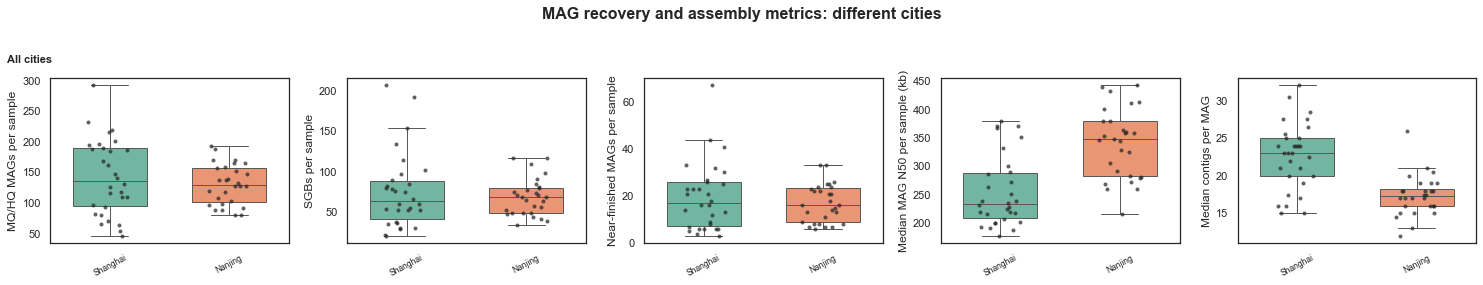

In [10]:
def plot_comparison(data, strata, filename, title):
    fig, axes = plt.subplots(
        len(strata), len(metric_cols),
        figsize=(4.15 * len(metric_cols), 3.9 * len(strata)),
        squeeze=False,
    )
    palette = sns.color_palette("Set2", n_colors=max(3, data["Group"].nunique()))
    for row, stratum in enumerate(strata):
        subset = data.loc[data["Stratum"].eq(stratum)].copy()
        order = list(subset["Group"].drop_duplicates())
        for col, metric in enumerate(metric_cols):
            ax = axes[row, col]
            plot_data = subset.copy()
            y = metric
            if metric == "MAG_N50_median":
                plot_data = plot_data.assign(MAG_N50_median=plot_data[metric] / 1000)
            sns.boxplot(
                data=plot_data, x="Group", y=y, order=order, ax=ax,
                palette=palette[:len(order)], width=0.62, showfliers=False,
            )
            sns.stripplot(
                data=plot_data, x="Group", y=y, order=order, ax=ax,
                color="#252525", alpha=0.72, size=4, jitter=0.18,
            )
            ax.set_xlabel("")
            ax.set_ylabel(metric_labels[metric])
            ax.tick_params(axis="x", rotation=28, labelsize=8.5)
            if col == 0:
                ax.text(
                    -0.18, 1.08, stratum, transform=ax.transAxes,
                    ha="left", va="bottom", fontsize=11, fontweight="bold",
                )
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()


plot_comparison(
    city_cmp, ["All cities"], "01_different_cities",
    "MAG recovery and assembly metrics: different cities",
)


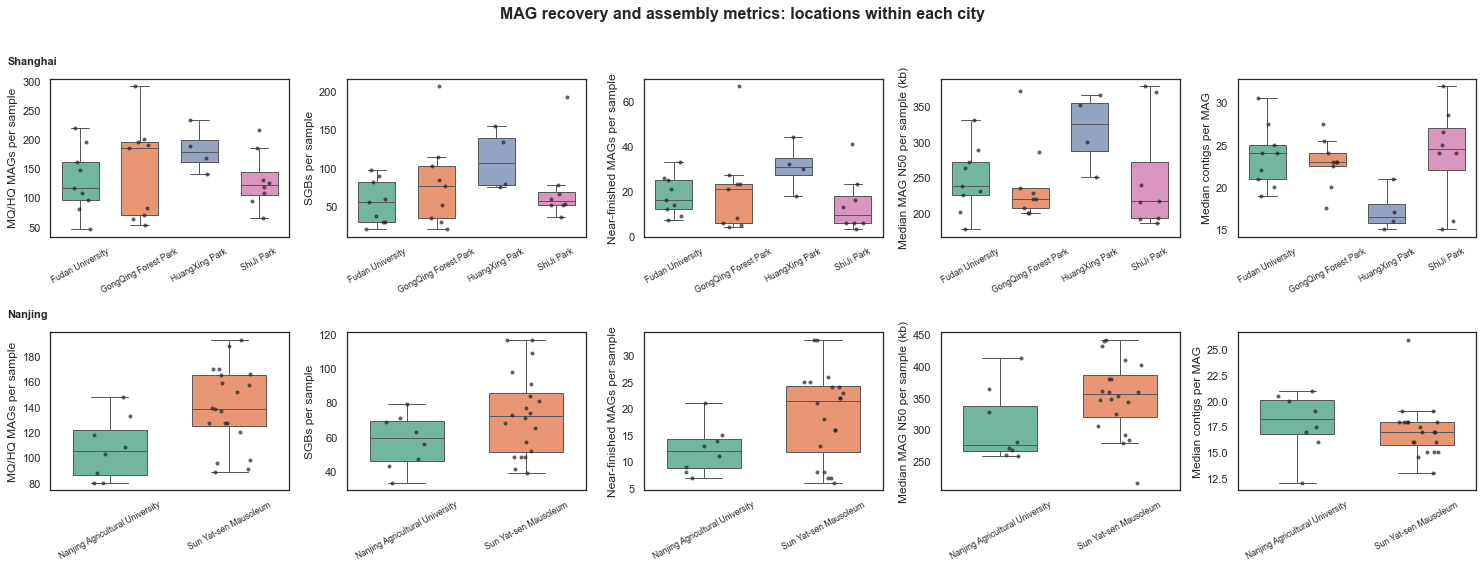

In [11]:
location_strata = list(location_cmp["Stratum"].drop_duplicates())
plot_comparison(
    location_cmp, location_strata, "02_locations_within_city",
    "MAG recovery and assembly metrics: locations within each city",
)


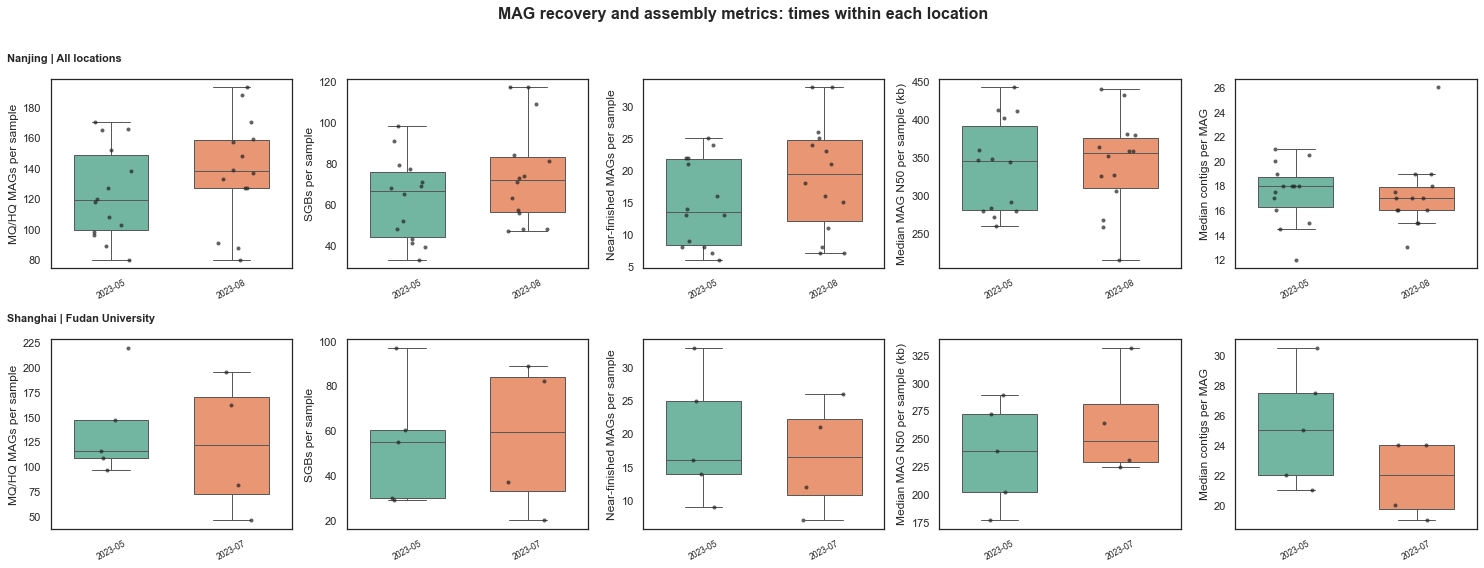

In [12]:
time_strata = list(time_cmp["Stratum"].drop_duplicates())
plot_comparison(
    time_cmp, time_strata, "03_times_within_location",
    "MAG recovery and assembly metrics: times within each location",
)


In [16]:
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh
from scipy.stats import rankdata
from matplotlib.lines import Line2D

abundance = pd.read_csv("../pre-calculated_data/mag_abundance.tsv", sep="\t")
rename = pd.read_csv("../pre-calculated_data/rename.csv")
required_abundance = {"MAG", "Relative abundance", "Sample"}

rename = rename.rename(columns={"Mag ID": "MAG", "identifier": "USMAG_ID"})
rename["CSMAG_ID"] = rename["USMAG_ID"].str.replace(r"^US", "CS", regex=True)
mag_lookup = mag[["Mag ID", "Sample", "SGB"]].rename(
    columns={"Mag ID": "CSMAG_ID", "Sample": "Annotated_sample"}
)
abundance = (
    abundance.merge(rename, on="MAG", how="left", validate="one_to_one")
    .merge(mag_lookup, on="CSMAG_ID", how="left", validate="one_to_one")
)

sgb_matrix = (
    abundance.pivot_table(
        index="Sample", columns="SGB", values="Relative abundance",
        aggfunc="sum", fill_value=0,
    )
    .reindex(meta["Sample_id"])
)

sgb_relative = sgb_matrix.div(sgb_matrix.sum(axis=1), axis=0)
sgb_relative = sgb_relative.loc[:, sgb_relative.mean(axis=0) >= 1e-5]

scaled = sgb_relative * 1_000_000
minimum_nonzero = scaled.to_numpy()[scaled.to_numpy() > 0].min()
pseudocount = minimum_nonzero / 2
log_sgb = np.log10(scaled.mask(scaled.eq(0), pseudocount))

bray_condensed = pdist(log_sgb.to_numpy(), metric="braycurtis")
bray_matrix = squareform(bray_condensed)

def classical_pcoa(distance_matrix):
    n = distance_matrix.shape[0]
    centering = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centering @ (distance_matrix ** 2) @ centering
    eigenvalues, eigenvectors = eigh(gram)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    positive = eigenvalues > 1e-12
    positive_values = eigenvalues[positive]
    coordinates = eigenvectors[:, positive] * np.sqrt(positive_values)
    explained = positive_values / positive_values.sum()
    return coordinates, positive_values, explained

pcoa_coordinates, pcoa_eigenvalues, pcoa_explained = classical_pcoa(bray_matrix)
pcoa_scores = pd.DataFrame(
    pcoa_coordinates[:, :2], index=log_sgb.index, columns=["PCoA1", "PCoA2"]
).reset_index(names="Sample_id")
pcoa_scores = pcoa_scores.merge(
    meta[["Sample_id", "City", "Location", "Time"]],
    on="Sample_id", how="left", validate="one_to_one",
)
pcoa_scores["Location_time"] = pcoa_scores["Location"] + ": " + pcoa_scores["Time"]

print(
    f"Explicitly mapped {len(abundance):,}/{len(abundance):,} abundance rows "
    f"through rename.csv to {abundance['SGB'].nunique():,} SGBs."
)
print(f"PCoA input after filtering: {log_sgb.shape[0]} samples × {log_sgb.shape[1]:,} SGBs.")
print(f"PCoA1: {pcoa_explained[0] * 100:.2f}%; PCoA2: {pcoa_explained[1] * 100:.2f}%.")
display(pcoa_scores.head())


Explicitly mapped 7,949/7,949 abundance rows through rename.csv to 4,171 SGBs.
PCoA input after filtering: 58 samples × 4,171 SGBs.
PCoA1: 14.35%; PCoA2: 7.22%.


,Sample_id,PCoA1,PCoA2,City,Location,Time,Location_time
0,sample1,-0.007566,0.001963,Shanghai,Fudan University,2023-05,Fudan University: 2023-05
1,sample2,-0.002815,-0.001006,Shanghai,Fudan University,2023-05,Fudan University: 2023-05
2,sample3,-0.002701,0.001188,Shanghai,Fudan University,2023-05,Fudan University: 2023-05
3,sample4,-0.002686,0.001304,Shanghai,Fudan University,2023-05,Fudan University: 2023-05
4,sample5,-0.001811,-0.000980,Shanghai,Fudan University,2023-05,Fudan University: 2023-05


In [17]:
def anosim_test(distance_matrix, labels, permutations=9_999, seed=20260701):
    labels = np.asarray(labels)
    n = len(labels)
    upper = np.triu_indices(n, k=1)
    ranked = rankdata(distance_matrix[upper], method="average")
    same = labels[upper[0]] == labels[upper[1]]
    if same.all() or (~same).all():
        raise ValueError("ANOSIM requires both within- and between-group distances.")
    divisor = n * (n - 1) / 4
    observed = (ranked[~same].mean() - ranked[same].mean()) / divisor
    rng = np.random.default_rng(seed)
    permuted_statistics = np.empty(permutations)
    for i in range(permutations):
        shuffled = rng.permutation(labels)
        perm_same = shuffled[upper[0]] == shuffled[upper[1]]
        permuted_statistics[i] = (
            ranked[~perm_same].mean() - ranked[perm_same].mean()
        ) / divisor
    p_value = (np.count_nonzero(permuted_statistics >= observed) + 1) / (permutations + 1)
    return observed, p_value

anosim_records = []

def add_anosim(comparison, stratum, indices, labels):
    indices = np.asarray(indices)
    subset_distance = bray_matrix[np.ix_(indices, indices)]
    statistic, p_value = anosim_test(subset_distance, labels)
    anosim_records.append({
        "Comparison": comparison,
        "Stratum": stratum,
        "Groups": len(pd.unique(labels)),
        "n_samples": len(labels),
        "R": statistic,
        "p_value": p_value,
        "Permutations": 9_999,
    })

score_meta = pcoa_scores.set_index("Sample_id").loc[log_sgb.index].reset_index()
all_indices = np.arange(len(score_meta))
add_anosim("City", "All samples", all_indices, score_meta["City"].to_numpy())
add_anosim(
    "Location-time", "All samples", all_indices,
    (score_meta["Location"] + " | " + score_meta["Time"]).to_numpy(),
)

for city, city_frame in score_meta.groupby("City", sort=False):
    idx = city_frame.index.to_numpy()
    if city_frame["Location"].nunique() > 1:
        add_anosim("Location within city", city, idx, city_frame["Location"].to_numpy())

for (city, location), location_frame in score_meta.groupby(["City", "Location"], sort=False):
    if location_frame["Time"].nunique() > 1:
        idx = location_frame.index.to_numpy()
        add_anosim(
            "Time within location", f"{city} | {location}",
            idx, location_frame["Time"].to_numpy(),
        )

anosim_results = pd.DataFrame(anosim_records)
anosim_results["p_bonferroni"] = np.minimum(anosim_results["p_value"] * len(anosim_results), 1.0)
display(anosim_results)


,Comparison,Stratum,Groups,n_samples,R,p_value,Permutations,p_bonferroni
0,City,All samples,2,58,0.278706,0.0001,9999,0.0007
1,Location-time,All samples,9,58,0.184206,0.0002,9999,0.0014
2,Location within city,Shanghai,4,30,0.135516,0.0064,9999,0.0448
3,Location within city,Nanjing,2,28,0.028039,0.3821,9999,1.0000
4,Time within location,Shanghai | Fudan University,2,9,-0.037500,0.5869,9999,1.0000
5,Time within location,Nanjing | Nanjing Agricultural University,2,8,-0.177083,0.8017,9999,1.0000
6,Time within location,Nanjing | Sun Yat-sen Mausoleum,2,20,0.009111,0.3663,9999,1.0000


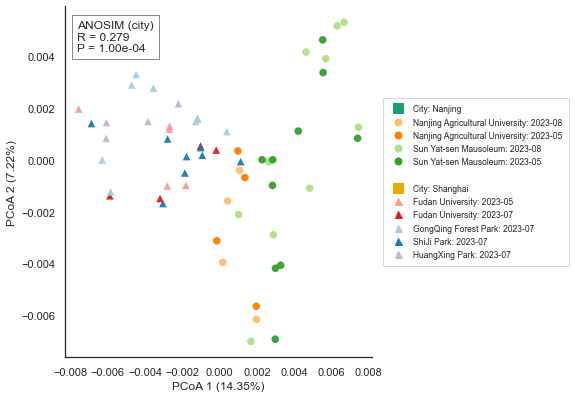

In [18]:
group_order = [
    ("Nanjing", "Nanjing Agricultural University", "2023-08", "#fdbf6f"),
    ("Nanjing", "Nanjing Agricultural University", "2023-05", "#ff7f00"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-08", "#b2df8a"),
    ("Nanjing", "Sun Yat-sen Mausoleum", "2023-05", "#33a02c"),
    ("Shanghai", "Fudan University", "2023-05", "#fb9a99"),
    ("Shanghai", "Fudan University", "2023-07", "#e31a1c"),
    ("Shanghai", "GongQing Forest Park", "2023-07", "#a6cee3"),
    ("Shanghai", "ShiJi Park", "2023-07", "#1f78b4"),
    ("Shanghai", "HuangXing Park", "2023-07", "#cab2d6"),
]
city_markers = {"Nanjing": "o", "Shanghai": "^"}

fig, ax = plt.subplots(figsize=(8.2, 5.7))
legend_handles = []
current_city = None
city_header_colors = {"Nanjing": "#1b9e77", "Shanghai": "#e6ab02"}

for city, location, time, color in group_order:
    if city != current_city:
        if current_city is not None:
            legend_handles.append(Line2D([], [], linestyle="none", label=" "))
        legend_handles.append(
            Line2D(
                [], [], marker="s", linestyle="none", markersize=10,
                markerfacecolor=city_header_colors[city],
                markeredgecolor=city_header_colors[city],
                label=f"City: {city}",
            )
        )
        current_city = city
    subset = pcoa_scores.loc[
        pcoa_scores["City"].eq(city)
        & pcoa_scores["Location"].eq(location)
        & pcoa_scores["Time"].eq(time)
    ]
    marker = city_markers[city]
    ax.scatter(
        subset["PCoA1"], subset["PCoA2"],
        color=color, marker=marker, s=58, edgecolor="none", alpha=0.95,
    )
    legend_handles.append(
        Line2D(
            [], [], marker=marker, linestyle="none", markersize=7,
            markerfacecolor=color, markeredgecolor=color,
            label=f"{location}: {time}",
        )
    )

city_test = anosim_results.loc[
    anosim_results["Comparison"].eq("City")
].iloc[0]
p_text = f"{city_test.p_value:.2e}" if city_test.p_value < 0.001 else f"{city_test.p_value:.3f}"
ax.text(
    0.04, 0.96,
    f"ANOSIM (city)\nR = {city_test.R:.3f}\nP = {p_text}",
    transform=ax.transAxes, ha="left", va="top",
    bbox={"facecolor": "white", "edgecolor": "#888888", "boxstyle": "square,pad=0.45"},
)

ax.set_xlabel(f"PCoA 1 ({pcoa_explained[0] * 100:.2f}%)")
ax.set_ylabel(f"PCoA 2 ({pcoa_explained[1] * 100:.2f}%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(
    handles=legend_handles, loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=True, fontsize=8.5, handletextpad=0.7, borderpad=0.8,
)
fig.tight_layout()
plt.show()